# Plotting TACs

The plotting library has a function to plot TACs of cluster centroids in a reasonable way. But there are infinite ways to visualize these data. This notebook shows some examples of loading cluster data and plotting them in unique ways.


In [1]:
""" Preliminaries, for developing and debugging in a python notebook.
    None of this is strictly necessary, but is useful for development.
"""

# Set up the path so our code is accessible w/o installing from pypi.
import sys, os
if os.path.abspath("..") not in sys.path:
    sys.path.insert(0, os.path.abspath(".."))

# Force automatic re-load of libraries on every call
# (useful for accelerated debugging of oft-changed library code)
%load_ext autoreload
%autoreload 2

print(f"Executing notebook from '{os.getcwd()}'")
print("System paths available:")
for p in sys.path:
    print(f"  {p}")

Executing notebook from '/home/mike/Projects/stare/stare_pet/examples'
System paths available:
  /home/mike/Projects/stare/stare_pet/examples
  /home/mike/Projects/stare/stare_pet
  /home/mike/Projects/stare/stare_pet/starelib
  /home/mike/Projects/stare/stare_pet/bin
  /usr/lib/python310.zip
  /usr/lib/python3.10
  /usr/lib/python3.10/lib-dynload
  
  /home/mike/.virtualenvs/stare/lib/python3.10/site-packages
  /home/mike/.virtualenvs/stare/lib/python3.10/site-packages/IPython/extensions
  /home/mike/.ipython


In [2]:
""" Context

    Specify the paths we're using for reading in data and writing out plots.
    These paths are all defined in this one block so you can change them,
    then just run the whole notebook without further modification.
"""

from pathlib import Path


# We recently ran stare on a subject here,
# so the output data are all there for the taking.
subject_stare_dir = Path("/home/mike/Projects/stare/stare_data/test_python/NHFDG004")

# This subject's original data are available elsewhere
subject_original_dir = Path("/home/mike/Projects/stare/stare_data/sampleData/NHFDG004")

# These are the files we'll need from the above-specified paths
first_centroids_file = subject_stare_dir / "cache" / "centroids_and_fits_step-1.pkl"
second_centroids_file = subject_stare_dir / "cache" / "centroids_and_fits_step-2.pkl"
timing_file = subject_original_dir / "NHFDG004.raw.midtime.txt"

# During this subject's stare run, we ignored the 8th volume,
# so it should be excised from the timing data.
ignored_frames = [8, ]


In [3]:
""" Load the data as specified above
"""

import pickle
import pandas as pd


# Load the lists of centroids and k-means fits stored during the stare run.
centroids_1, fits_1 = pickle.load(first_centroids_file.open("rb"))
centroids_2, fits_2 = pickle.load(second_centroids_file.open("rb"))

# Load timing data, and name its one column so it's more intuitive to use.
timing_data = pd.read_csv(timing_file, header=None)
timing_data.columns = ["t", ]

# Remove any data we ignored during the stare run so data line up.
# These are zero-indexed, so subtract one from the one-indexed list.
timing_data = timing_data.drop([i - 1 for i in ignored_frames])


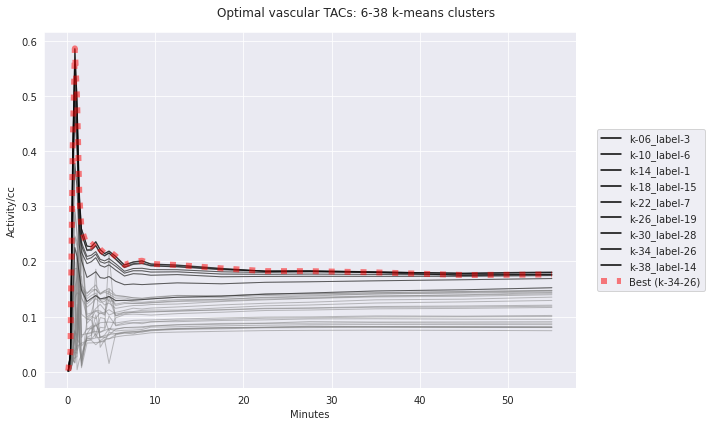

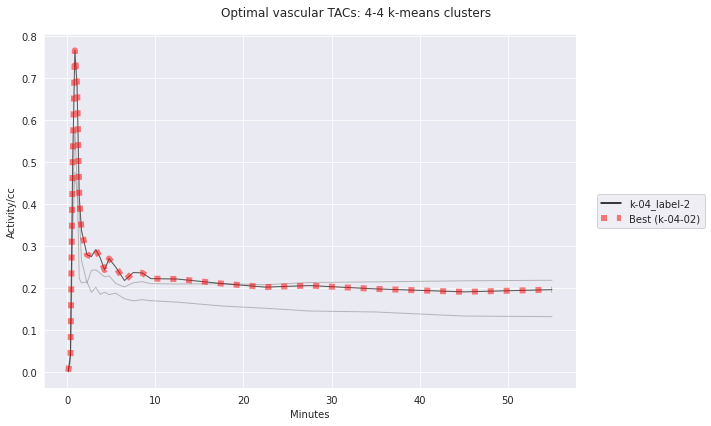

In [4]:
""" Try doing this the way the normal stare pipeline does it.
"""

from src.starelib import plotting


fig_standard_1 = plotting.plot_tacs(plotting.centroids_to_plottable_tacs(centroids_1, timing_data))
fig_standard_2 = plotting.plot_tacs(plotting.centroids_to_plottable_tacs(centroids_2, timing_data))


That's that. We've loaded data from the stare pipeline and plotted the TACs for the first and second vascular clustering.

We may want to see more of the first timepoints, and we can do that by using a log-scale on the x-axis.

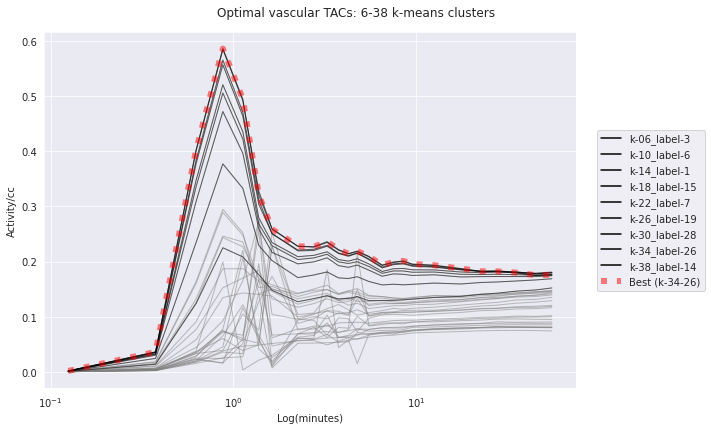

In [5]:
fig_standard_1.axes[0].set_xscale('log')
fig_standard_1.axes[0].set_xlabel('Log(minutes)')
fig_standard_1


We may want to look at all cluster centroids, and highlight the best, so we can assess selection performance and compare the two layers of k-means. To do that, I've copied the function for plotting tacs from the starelib plotting library and modified it to suit our purposes. After defining that modified plotting function, I plot both layers of k-means centroids onto the same axes.

In [6]:
plottable_centroids_1 = plotting.centroids_to_plottable_tacs(centroids_1, timing_data)
plottable_centroids_2 = plotting.centroids_to_plottable_tacs(centroids_2, timing_data)


In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


def plot_tacs(data, vascular_color='black', highlight_color='red', ax=None):
    """ Plot a time activity curve (TAC)

        Given a long-format dataframe with TACs and their metadata,
        return a figure with their line plots.

        :param DataFrame data: The TACs to plot
        :param vascular_color: The color of lines representing the best vascular TACs for each value of k
        :param highlight_color: The color of highlight laid over the best of all vascular TACs
        :param ax: Optionally draw on your own axes
        :returns Figure:
    """

    if ax is None:
        fig, axes = plt.subplots(figsize=(10, 6))
    else:
        fig, axes = ax.get_figure(), ax

    # Force seaborn to treat K as categorical rather than continuous
    data.loc[:, 'K'] = data['k'].apply(lambda k: f"{k:02d}")

    # Create a unique id for each k/label combination,
    # allows seaborn to plot lines individually rather than estimate their mean/ci
    data.loc[:, 'run'] = data.apply(lambda row: f"k-{row['k']:02d}_label-{row['label']}", axis=1)

    # Create color palettes that make all hues identical
    num_gray_lines = len(data[data['vascular']]['run'].unique())
    grays = ['gray', ] * num_gray_lines
    print(f"made a palette of {num_gray_lines} gray values.")
    num_vasc_lines = len(data[data['best_in_k']]['run'].unique())
    vascs = [vascular_color, ] * num_vasc_lines
    print(f"made a palette of {num_vasc_lines} vascular best-in-k values.")

    # Plot every single centroid as light gray to provide context.
    # These are plotted first to set them as background.
    sns.lineplot(data=data[data['vascular']], x='t', y='activity', hue='run',
                 palette=grays, alpha=0.5, linewidth=1, legend=False, ax=axes)

    # Next, plot the centroids that are the best for their k-means group
    sns.lineplot(data=data[data['best_in_k']], x="t", y="activity", hue='run',
                 palette=vascs, alpha=0.5, linewidth=1, label="", ax=axes)

    # Finally, plot the very best centroid of the whole batch.
    best_k = data[data['best_overall']]['k'].unique()[0]
    best_label = data[data['best_overall']]['label'].unique()[0]
    sns.lineplot(data=data[data['best_overall']], x="t", y="activity",
                 color=highlight_color, linestyle=":", linewidth=6, alpha=0.5,
                 label=f"Best (k-{best_k:02d}-{best_label:02d})", ax=axes)

    # Finish off the details so the plot is readable.
    axes.set_xlabel("Minutes")  # ranges 0 to 60
    axes.set_ylabel("Activity/cc")  # ranges -0.05 to +0.30
    axes.legend(bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0)
    fig.suptitle(f"Optimal vascular TACs: {data['k'].min()}-{data['k'].max()}"
                 " k-means clusters")
    fig.tight_layout()

    return fig


made a palette of 32 gray values.
made a palette of 9 vascular best-in-k values.
made a palette of 3 gray values.
made a palette of 1 vascular best-in-k values.


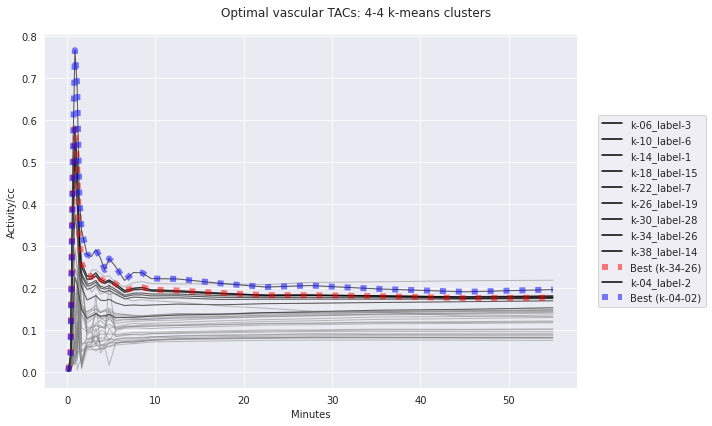

In [8]:
# Generate the plot, as designed, for the first level k-means.
fig_fuller_1 = plot_tacs(plottable_centroids_1, highlight_color='red')

# And add the second-level k-means on top of the same axes used for the first plot.
fig_fuller_1 = plot_tacs(plottable_centroids_2, ax=fig_fuller_1.axes[0], highlight_color='blue')

# Save it to disk
fig_fuller_1.savefig(subject_stare_dir / "anchoring" / "figs-masks" / "level_1_kmeans_centroids.png")


What would be really nice, though, at this stage, is to overlay information from running these same data with the matlab version of this code. Internally, we have these data, but this would not work for anyone else. So I have manually copied the values from our matlab run of the same data to here, so you can still run this. Either way, I hope you gain inspiration from the code for continuing to draw other comparison lines onto this plot.

Matlab data came from the out.vascClust.step1MeanTacs matrix.

In [9]:
""" Store all matlab data as a list of dicts,
    then they convert beautifully into a dataframe
    that plots seamlessly.
"""

manually_built_matlab_data = []

matlab_step_one_best_tacs = {
    "NHFDG002": ([
        0.000050891587946, 0.003811011320078, 0.067509741709583, 0.183693005849300,
        0.264125691030853, 0.234669752984070, 0.215735773955863, 0.182815820084233,
        0.173694787863867, 0.178278871129786, 0.171271552686368, 0.176254990593437,
        0.172649371633499, 0.165133695007445, 0.156740416833876, 0.163967287784933,
        0.161914061639467, 0.160204638404769, 0.156131343962827, 0.158187969469648,
        0.159966019071184, 0.161680785662739, 0.166795467022087, 0.173177676475539,
        0.177939388398845,
    ], 1, 38, 21, ),
    "NHFDG003": ([
        0.001819101500763, 0.036485924977800, 0.403419809084210, 0.589168181288676,
        0.491843119723279, 0.319869130509242, 0.260245352821124, 0.227242728546474,
        0.225277173359008, 0.234204453632061, 0.219803438707423, 0.212525830318775,
        0.215235460187913, 0.208246560371990, 0.192467185020244, 0.197984669137348,
        0.199900138789465, 0.193949515967182, 0.192445354031428, 0.186009810998247,
        0.181156839721052, 0.180884980982000, 0.178581603588517, 0.173724731983991,
        0.174536500427384,
    ], 1, 30, 30, ),
    "NHFDG004": ([
        -0.000129770576477812, 0.00128374909313924, 0.0805627800664694, 0.324819647240401,
        0.466500976723846, 0.413232726690569, 0.253275932093271, 0.196734447292701,
        0.182558666677239, 0.176392827263852, 0.176894471721632, 0.177076168724771,
        0.172669212333524, 0.170574445584569, 0.165290748461194, 0.162309247170925,
        0.154940204379793, 0.153011963187960, 0.148671024292722, 0.145730104109475,
        0.144700051910953, 0.141397430230763, 0.141756216314435, 0.140574338176758,
        0.140835404596981,
    ], 1, 0, 0, ),
}
matlab_step_two_best_tacs = {
    "NHFDG002": ([
        0.000226494556387, 0.003768011862738, 0.108326192004576, 0.274181799866604,
        0.392731220025225, 0.354088167788771, 0.282590110009070, 0.240693793213152,
        0.204929380560345, 0.234923234053378, 0.189874502983327, 0.213624119997089,
        0.190944360605099, 0.194905227072847, 0.186874492693560, 0.193513005942965,
        0.187521503838365, 0.171913824001259, 0.179246071961663, 0.175959090491916,
        0.171909378375615, 0.174391964974754, 0.176332305650625, 0.179919460114750,
        0.180508809803182,
    ], 2, 4, 3, ),
    "NHFDG003": ([
        -0.000363272874408, 0.039802204065439, 0.493027927485756, 0.759060974608281,
        0.679994332354537, 0.409231742065071, 0.335337139651014, 0.279500904022888,
        0.272459786813210, 0.291629139333425, 0.272393059526400, 0.242578239061638,
        0.271126802530197, 0.248666201841095, 0.219873091179122, 0.237817239537791,
        0.236845258383704, 0.221867297806237, 0.221932284310425, 0.212172333327783,
        0.204173375041157, 0.208599358513649, 0.201215793252242, 0.195229039080953,
        0.200267890044478,
    ], 2, 3, 4, ),
    "NHFDG004": ([
        -0.000123075483317230, 0.00178606454965395, 0.0938256748407611, 0.421533812814269,
        0.600252120333256, 0.547252544408538, 0.287430249379561, 0.218024033374195,
        0.197436647390347, 0.203020303496733, 0.198863796423642, 0.201627529463339,
        0.190725365283387, 0.194577462467333, 0.188149238929710, 0.182408596378904,
        0.174149912857304, 0.167293991620415, 0.168985802860849, 0.165826070686030,
        0.164220163975366, 0.159984764281404, 0.163025971181240, 0.159557628316763,
        0.161819038635883,
    ], 2, 0, 0, ),
}

for activity, step, k, label in [
    matlab_step_one_best_tacs["NHFDG004"],
    matlab_step_two_best_tacs["NHFDG004"],
]:
    for i in range(len(timing_data)):
        manually_built_matlab_data.append(
            {
                "t": timing_data.iloc[i, 0],
                "k": k,
                "label": label,
                "best_overall": True,
                "best_in_k": True,
                "vascular": True,
                "step": step,
                "activity": activity[i],
            }
        )

matlab_step_1 = pd.DataFrame([d for d in manually_built_matlab_data if d['step'] == 1])
matlab_step_2 = pd.DataFrame([d for d in manually_built_matlab_data if d['step'] == 2])

pd.concat([matlab_step_1, matlab_step_2, ])


,t,k,label,best_overall,best_in_k,vascular,step,activity
0,0.125,34,26,True,True,True,1,0.001819
1,0.375,34,26,True,True,True,1,0.036486
2,0.625,34,26,True,True,True,1,0.403420
3,0.875,34,26,True,True,True,1,0.589168
4,1.125,34,26,True,True,True,1,0.491843
5,1.375,34,26,True,True,True,1,0.319869
6,1.625,34,26,True,True,True,1,0.260245
7,2.250,34,26,True,True,True,1,0.227243
8,2.750,34,26,True,True,True,1,0.225277
9,3.250,34,26,True,True,True,1,0.234204


made a palette of 1 gray values.
made a palette of 1 vascular best-in-k values.
made a palette of 1 gray values.
made a palette of 1 vascular best-in-k values.


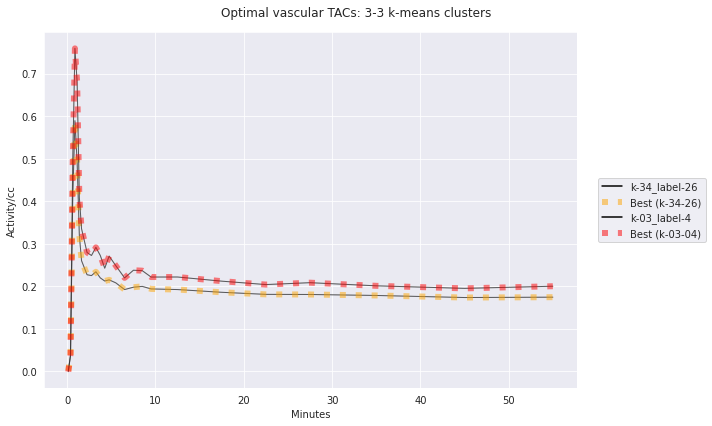

In [10]:
""" Plot matlab data by itself to see how it works out.
"""

fig_matlab = plot_tacs(matlab_step_1, highlight_color='orange')
fig_matlab = plot_tacs(matlab_step_2, highlight_color='red', ax=fig_matlab.axes[0])


made a palette of 1 gray values.
made a palette of 1 vascular best-in-k values.
made a palette of 1 gray values.
made a palette of 1 vascular best-in-k values.


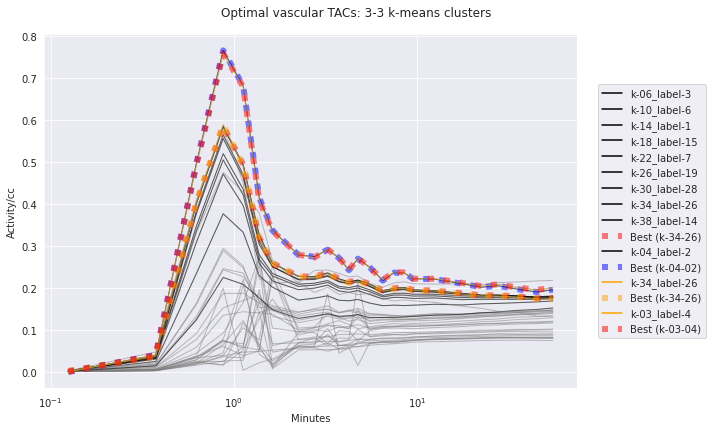

In [11]:
""" That was fine. Add those four lines to our previous plot.
"""

fig_fuller_1 = plot_tacs(matlab_step_1, ax=fig_fuller_1.axes[0], vascular_color='orange', highlight_color='orange')
fig_fuller_1 = plot_tacs(matlab_step_2, ax=fig_fuller_1.axes[0], vascular_color='orange', highlight_color='red')
fig_fuller_1.axes[0].set_xscale('log')

# Save it to disk
fig_fuller_1.savefig(subject_stare_dir / "anchoring" / "figs-masks" / "all_kmeans_centroids.png")

fig_fuller_1